In [ ]:
import os

# 1. Force Hugging Face à télécharger dans le projet
os.environ["HF_HOME"] = "./hf_cache"

# 2. Force Hugging Face à ignorer le fichier de token local (qui bloque)
os.environ["HF_HUB_DISABLE_TOKEN"] = "1"

print("Dossier de cache configuré sur :", os.environ["HF_HOME"])
print("Vérification du token désactivée pour éviter l'erreur de permission.")



📂 Chargement du set de test...
🧠 Chargement du modèle depuis : ./curriculum-phase2-final/checkpoint-602

🎯 RÉSULTATS GLOBAUX (PHASE 2)
Macro F1-score : 0.9103 (Cible : >= 0.82)
Accuracy       : 0.9027

📝 RAPPORT DÉTAILLÉ :
                      precision    recall  f1-score   support

             Support       0.89      0.91      0.90       209
     Feature Request       1.00      1.00      1.00       102
Billing and Payments       0.85      0.82      0.83       131

            accuracy                           0.90       442
           macro avg       0.91      0.91      0.91       442
        weighted avg       0.90      0.90      0.90       442


📊 Matrice de confusion sauvegardée sous : docs/images/final_confusion_matrix.png
🚨 43 VRAIES erreurs extraites pour l'audit manuel : data/qualitative_analysis_errors.csv


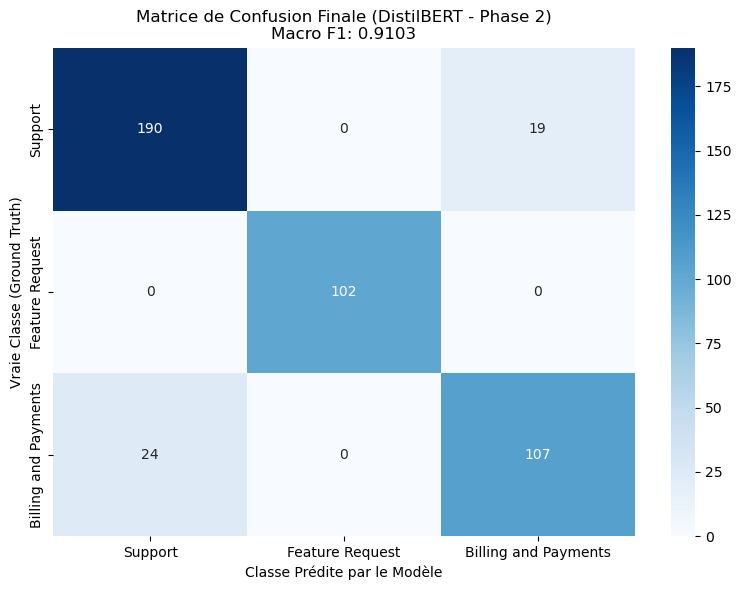

In [4]:
# src/evaluate_final_model.py
import os

# --- AJOUT CRUCIAL POUR CONTOURNER L'ERREUR DE PERMISSION ---
# Force Hugging Face à utiliser un cache local dans le projet
os.environ["HF_HOME"] = "./hf_cache"
# Désactive complètement la lecture du token (inutile pour DistilBERT qui est public)
os.environ["HF_HUB_DISABLE_TOKEN"] = "1"
# -----------------------------------------------------------

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

DEVICE = torch.device("cpu") # Ou "cuda"/"mps" si disponible

# ==========================================
# 1. CHARGEMENT DES DONNÉES DE TEST ET DU MODÈLE
# ==========================================
print("📂 Chargement du set de test...")
test_df = pd.read_csv('data/test.csv')

# Mapping validé par l'équipe
label_mapping = {"Support": 0, "Feature Request": 1, "Billing and Payments": 2}
inverse_mapping = {v: k for k, v in label_mapping.items()}

MODEL_PATH = "./curriculum-phase2-final/checkpoint-602"
print(f"🧠 Chargement du modèle depuis : {MODEL_PATH}")
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(MODEL_PATH).to(DEVICE)
model.eval()

# ✅ LIGNE CORRIGÉE (On utilise le map pour convertir le texte en 0, 1, 2) :
true_labels = test_df['label'].map(label_mapping).tolist()

# Tokenisation par batch
inputs = tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1).cpu().numpy()

# ==========================================
# 3. CALCUL DES MÉTRIQUES (Macro F1 & Accuracy)
# ==========================================
macro_f1 = f1_score(true_labels, predictions, average='macro')
accuracy = accuracy_score(true_labels, predictions)

print("\n" + "="*40)
print(f"🎯 RÉSULTATS GLOBAUX (PHASE 2)")
print("="*40)
print(f"Macro F1-score : {macro_f1:.4f} (Cible : >= 0.82)")
print(f"Accuracy       : {accuracy:.4f}")
print("\n📝 RAPPORT DÉTAILLÉ :")
print(classification_report(true_labels, predictions, target_names=list(label_mapping.keys())))

# ==========================================
# 4. GÉNÉRATION DE LA MATRICE DE CONFUSION
# ==========================================
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(label_mapping.keys()),
            yticklabels=list(label_mapping.keys()))
plt.title(f'Matrice de Confusion Finale (DistilBERT - Phase 2)\nMacro F1: {macro_f1:.4f}')
plt.ylabel('Vraie Classe (Ground Truth)')
plt.xlabel('Classe Prédite par le Modèle')
plt.tight_layout()

cm_path = 'docs/images/final_confusion_matrix.png'
plt.savefig(cm_path)
print(f"\n📊 Matrice de confusion sauvegardée sous : {cm_path}")

# ==========================================
# 5. EXTRACTION DES ERREURS POUR L'ANALYSE QUALITATIVE
# ==========================================
# On traduit les prédictions (chiffres) en texte pour pouvoir les comparer avec le CSV
test_df['predicted_label_text'] = [inverse_mapping[p] for p in predictions]

# On filtre les VRAIES erreurs (Texte vs Texte)
errors_df = test_df[test_df['label'] != test_df['predicted_label_text']].copy()

errors_df = errors_df.rename(columns={'label': 'vrai_nom', 'predicted_label_text': 'nom_predit'})

errors_path = 'data/qualitative_analysis_errors.csv'
errors_df[['text', 'vrai_nom', 'nom_predit']].to_csv(errors_path, index=False)

print(f"🚨 {len(errors_df)} VRAIES erreurs extraites pour l'audit manuel : {errors_path}")